# Ejercicio 01  MLP Keras: Iris

Copia de trabajo. Se conserva la corrida original `4 x 3 x 3`, se agregan exactamente dos capas ocultas para `4 x 3 x 3 x 3 x 3` y se incluye el reto opcional.

## Parte A: Corrida orginal `4 x 3 x 3`

La red tiene una capa oculta de tres neuronas y una salida de tres neuronas. Usamos sigmoide, MSE, SGD con `learning_rate=0.03` y 500 epocas.

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from sklearn import datasets
import time

SEED = 123
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [15]:
iris = datasets.load_iris()
X = iris.data
target = iris.target
Y = to_categorical(target).astype("uint8")
# 0 => [1 0 0]
# 1 => [0 1 0]
# 2 => [0 0 1]

In [16]:
idx = 0
print(X[idx])
print(target[idx])
print(Y[idx])

[5.1 3.5 1.4 0.2]
0
[1 0 0]


In [17]:
model = keras.Sequential(
  [
    layers.Dense(3, activation="sigmoid", name="layer1", input_shape=(4,)),
    layers.Dense(3, activation="sigmoid", name="layer2"),
  ]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 3)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27 (108.00 B)

 Trainable params: 27 (108.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.03)
loss = tf.keras.losses.MeanSquaredError()

model.compile(optimizer=optimizer, loss=loss, metrics=["accuracy"])

t0 = time.perf_counter()
history = model.fit(X, Y, epochs=500, verbose=0)
t_orig = time.perf_counter() - t0

orig_loss = history.history["loss"]
orig_acc = history.history["accuracy"]
print(f"Original 4x3x3 - Error inicial: {orig_loss[0]:.6f} | Error final: {orig_loss[-1]:.6f} | Accuracy final: {orig_acc[-1]:.4f} | Tiempo: {t_orig:.2f} s")

Original 4x3x3 - Error inicial: 0.263725 | Error final: 0.165915 | Accuracy final: 0.6667 | Tiempo: 28.28 s


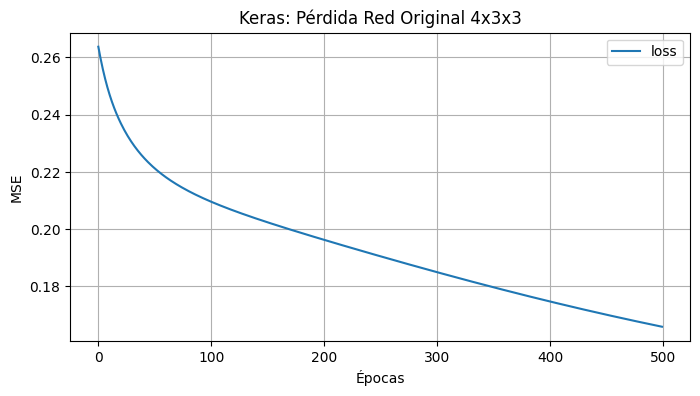

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Predicción de ejemplo [3, 3, 1, 1]: [[0.52891076 0.3519832  0.29999715]]


In [19]:
pd.DataFrame(history.history["loss"], columns=["loss"]).plot(figsize=(8, 4))
plt.title("Keras: Pérdida Red Original 4x3x3")
plt.xlabel("Épocas")
plt.ylabel("MSE")
plt.grid(True)
plt.show()

sample_pred = model.predict(np.array([[3, 3, 1, 1]]))
print("Predicción de ejemplo [3, 3, 1, 1]:", sample_pred)

## Parte B: Modelo Profundo `4 x 3 x 3 x 3 x 3`

In [20]:
# Arquitectura profunda: 4 entradas, 3 ocultas de 3 neuronas, 1 salida de 3 neuronas
model_deep = keras.Sequential(
  [
    layers.Dense(3, activation="sigmoid", name="deep_layer1", input_shape=(4,)),
    layers.Dense(3, activation="sigmoid", name="deep_layer2"),
    layers.Dense(3, activation="sigmoid", name="deep_layer3"),
    layers.Dense(3, activation="sigmoid", name="deep_layer4"),
  ]
)

model_deep.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ deep_layer1 (Dense)             │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ deep_layer2 (Dense)             │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ deep_layer3 (Dense)             │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ deep_layer4 (Dense)             │ (None, 3)              │            12 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 51 (204.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
optimizer_deep = tf.keras.optimizers.SGD(learning_rate=0.03)
loss_deep = tf.keras.losses.MeanSquaredError()

model_deep.compile(optimizer=optimizer_deep, loss=loss_deep, metrics=["accuracy"])

t0_deep = time.perf_counter()
history_deep = model_deep.fit(X, Y, epochs=500, verbose=0)
t_deep = time.perf_counter() - t0_deep

deep_loss = history_deep.history["loss"]
deep_acc = history_deep.history["accuracy"]
print(f"Profunda 4x3x3x3x3 - Error inicial: {deep_loss[0]:.6f} | Error final: {deep_loss[-1]:.6f} | Accuracy final: {deep_acc[-1]:.4f} | Tiempo: {t_deep:.2f} s")

Profunda 4x3x3x3x3 - Error inicial: 0.245969 | Error final: 0.221961 | Accuracy final: 0.3333 | Tiempo: 28.23 s


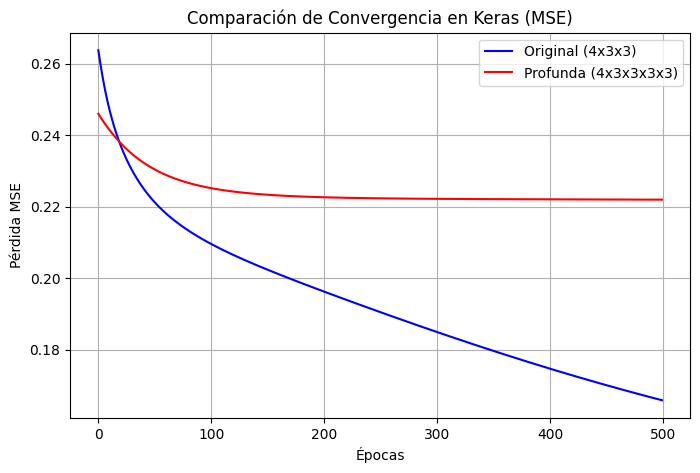

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(orig_loss, label="Original (4x3x3)", color="blue")
plt.plot(deep_loss, label="Profunda (4x3x3x3x3)", color="red")
plt.xlabel("Épocas")
plt.ylabel("Pérdida MSE")
plt.title("Comparación de Convergencia en Keras (MSE)")
plt.grid(True)
plt.legend()
plt.show()

## Reto opcional  aplanamiento cada 50 epocas

In [23]:
print("=" * 60)
print(f"{'Época':^8} | {'Error Keras (4x3x3)':^22} | {'Error Keras (4x3x3x3x3)':^22}")
print("=" * 60)

for epoch in range(0, len(orig_loss), 50):
    print(f"{epoch:^8d} | {orig_loss[epoch]:^22.6f} | {deep_loss[epoch]:^22.6f}")

if (len(orig_loss) - 1) % 50 != 0:
    last_ep = len(orig_loss) - 1
    print(f"{last_ep:^8d} | {orig_loss[last_ep]:^22.6f} | {deep_loss[last_ep]:^22.6f}")

print("=" * 60)

 Época   |  Error Keras (4x3x3)   | Error Keras (4x3x3x3x3)
   0     |        0.263725        |        0.245969       
   50    |        0.221196        |        0.230388       
  100    |        0.209560        |        0.225166       
  150    |        0.202363        |        0.223328       
  200    |        0.196249        |        0.222626       
  250    |        0.190487        |        0.222331       
  300    |        0.184954        |        0.222189       
  350    |        0.179679        |        0.222108       
  400    |        0.174714        |        0.222051       
  450    |        0.170095        |        0.222004       
  499    |        0.165915        |        0.221961       


## Reto opcional A Cambio de función de activación (ReLU + Softmax + Crossentropy)

Reto ReLU/Softmax | Pérdida final: 1.099081 | Accuracy: 0.3333


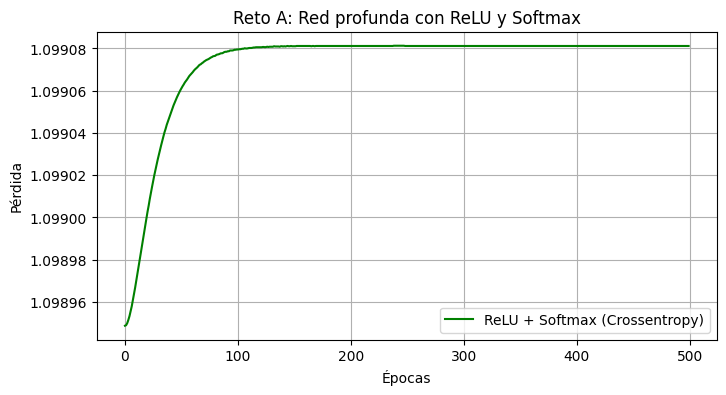

In [24]:
# Reto: 3 capas ocultas ReLU, salida Softmax, función de costo CategoricalCrossentropy
model_relu = keras.Sequential(
  [
    layers.Dense(3, activation="relu", name="relu_hidden1", input_shape=(4,)),
    layers.Dense(3, activation="relu", name="relu_hidden2"),
    layers.Dense(3, activation="relu", name="relu_hidden3"),
    layers.Dense(3, activation="softmax", name="softmax_output"),
  ],
  name="iris_relu_softmax"
)

model_relu.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.03),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=["accuracy"]
)

history_relu = model_relu.fit(X, Y, epochs=500, verbose=0)
eval_relu = model_relu.evaluate(X, Y, verbose=0)
print(f"Reto ReLU/Softmax | Pérdida final: {history_relu.history['loss'][-1]:.6f} | Accuracy: {eval_relu[1]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(history_relu.history['loss'], color="green", label="ReLU + Softmax (Crossentropy)")
plt.xlabel("Épocas")
plt.ylabel("Pérdida")
plt.title("Reto A: Red profunda con ReLU y Softmax")
plt.grid(True)
plt.legend()
plt.show()

## Reto opcional B Capas ocultas más anchas (8 neuranas por capa oculta)

In [25]:
# Reto: Topología 4 x 8 x 8 x 8 x 3 con activación sigmoide y MSE
model_wide = keras.Sequential(
  [
    layers.Dense(8, activation="sigmoid", name="wide_hidden1", input_shape=(4,)),
    layers.Dense(8, activation="sigmoid", name="wide_hidden2"),
    layers.Dense(8, activation="sigmoid", name="wide_hidden3"),
    layers.Dense(3, activation="sigmoid", name="wide_output"),
  ],
  name="iris_wide"
)

model_wide.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.03),
    loss=tf.keras.losses.MeanSquaredError(),
    metrics=["accuracy"]
)

history_wide = model_wide.fit(X, Y, epochs=500, verbose=0)
eval_wide = model_wide.evaluate(X, Y, verbose=0)
print(f"Reto 8x8x8 | Pérdida final: {history_wide.history['loss'][-1]:.6f} | Accuracy: {eval_wide[1]:.4f}")

Reto 8x8x8 | Pérdida final: 0.221487 | Accuracy: 0.3333
